# Talos RAG Evaluation — v3

Reproducible end-to-end evaluation of the Talos RAG pipeline. Methodology, citations, and the protocol-upgrade list live in [`EVALUATION_PLAN.md`](EVALUATION_PLAN.md).

**v3 upgrades over v2** (every change is grounded in a paper cited in the plan):

* New variant **`production_default`** — matches `src/config/config.py` exactly (dense + cross-encoder rerank, no rewriting / HyDE / hybrid / compression). This is the configuration the report should headline.
* New variant **`compression_calibrated`** — same as the everything-on stress test but with `EmbeddingsFilter` threshold dropped from 0.76 → 0.50. Tests whether the v2 compression regression is a config bug rather than a method bug.
* `full_system` renamed → **`everything_on_stress`** so nobody mistakes it for the deployed config.
* Retrieval IR reported at **both k=5 (production) and k=10 (BEIR convention** — Thakur et al. 2021).
* **Counterfactual-noise diagnostic** broken out per category (Yoran et al., ICLR 2024).
* **Closed-book lift** broken out per category (Mallen et al., ACL 2023).
* New plot: **Δ vs. baseline + significance** panel (Dror et al., ACL 2018).
* New cell: **2-judge consistency check on a 10-question slice** (Zheng et al., NeurIPS 2023, §4).
* New cell: **human-calibration scaffold** — exports a CSV for hand-rating, then computes Pearson + Spearman of LLM-judge vs. human (Es et al., EACL 2024 §4; Saad-Falcon et al., NAACL 2024).
* New cell: **compression-threshold sweep** — runs the embeddings filter at thresholds 0.30 → 0.76 to recommend a calibrated value for the production config.
* HotpotQA opt-in cell unchanged.

## 0 · Setup

In [25]:
from __future__ import annotations

import json
import os
import sys
import time
import warnings
from collections import Counter, defaultdict
from dataclasses import asdict
from pathlib import Path

from dotenv import load_dotenv
load_dotenv(Path('..') / '.env')
load_dotenv()

ROOT = Path('..').resolve()
for p in (ROOT, ROOT / 'src'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import importlib
import eval_utils
importlib.reload(eval_utils)
import eval_utils as eu
print(eu.env_check())

{'OPENAI_API_KEY': True, 'src_on_path': True, 'corpus_default': True}


In [26]:
SEED = 42
N_ARTICLES = 200
N_QUESTIONS = {'single_hop_specific': 30, 'multi_hop_specific': 15, 'multi_hop_abstract': 15}
MIN_TEST_SET_SIZE = 30
MIN_N_FOR_STATS   = 30
TOP_K = 5
BEIR_K = 10
GENERATOR_MODEL = 'gpt-4o-mini'
JUDGE_MODEL     = 'gpt-4o-mini'
ALT_JUDGE_MODEL = 'gpt-4o'        # for the 2-judge consistency check (set None to skip)
EMBEDDING_MODEL = 'text-embedding-3-small'

# Opt-in flags
RUN_HOTPOT          = True # human-authored multi-hop slice, requires HuggingFace dl
RUN_2JUDGE          = True   # 2-judge consistency on 10-question slice (extra ~$0.10)
RUN_COMP_SWEEP      = True   # compression-threshold sweep on dense_only (~$0.05)
EXPORT_CALIBRATION  = True   # write evaluation/human_calibration_template.csv for hand-rating

CORPUS_PATH = Path('en_wikipedia_cs.pkl')
RUN_DIR = Path('runs') / time.strftime('%Y%m%d-%H%M%S')
RUN_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = Path('.cache')
CACHE_DIR.mkdir(exist_ok=True)
print('Run dir:', RUN_DIR)

Run dir: runs/20260428-092956


## 1 · Load and chunk the corpus

In [27]:
docs = eu.load_corpus(CORPUS_PATH, max_articles=N_ARTICLES, seed=SEED)
chunks = eu.chunk_documents(docs, chunk_size=1000, chunk_overlap=200)
chunks_by_id = {c.metadata['chunk_id']: c for c in chunks}
print(f'Loaded {len(docs)} articles, {len(chunks)} chunks')

Loaded 200 articles, 6640 chunks


## 2 · Models

In [28]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)
generator  = ChatOpenAI(model=GENERATOR_MODEL, temperature=0)
judge      = ChatOpenAI(model=JUDGE_MODEL,     temperature=0)
alt_judge  = ChatOpenAI(model=ALT_JUDGE_MODEL,  temperature=0) if (RUN_2JUDGE and ALT_JUDGE_MODEL) else None

## 3 · Synthesize the test set

In [29]:
qa_cache = Path('qa_set.json')
qa_items = []
if qa_cache.exists():
    cached = [eu.QAItem(**d) for d in json.loads(qa_cache.read_text())]
    if len(cached) >= MIN_TEST_SET_SIZE:
        qa_items = cached
        print(f'Using cached test set ({len(qa_items)} items)')
    else:
        print(f'Cached test set too small ({len(cached)} < {MIN_TEST_SET_SIZE}); regenerating.')
        qa_cache.unlink()

if not qa_items:
    raw = eu.synthesize_qa(
        chunks, judge,
        embeddings_model=embeddings,
        n_per_category=N_QUESTIONS,
        seed=SEED, progress=print,
    )
    print(f'Generated {len(raw)} candidates; reviewing…')
    qa_items = eu.review_qa(raw, judge, embeddings_model=embeddings)
    qa_cache.write_text(json.dumps([asdict(q) for q in qa_items], indent=2))
    print(f'Kept {len(qa_items)} after review')

if len(qa_items) < MIN_TEST_SET_SIZE:
    warnings.warn(
        f'Only {len(qa_items)} test items survived; results below this threshold '
        f'({MIN_TEST_SET_SIZE}) are NOT statistically defensible.'
    )
print('Category mix:', dict(Counter(q.category for q in qa_items)))

Using cached test set (49 items)
Category mix: {'single_hop_specific': 24, 'multi_hop_specific': 11, 'multi_hop_abstract': 14}


## 4 · Build shared vectorstores

In [30]:
print('Building base vectorstore…')
base_vs = eu.build_vectorstore(chunks, embeddings)
print('Building HyDE vectorstore…')
hyde_emb = eu._hyde_embeddings(embeddings, generator)
hyde_vs  = eu.build_vectorstore(chunks, hyde_emb)
print('Done.')

Building base vectorstore…
Building HyDE vectorstore…
Done.


## 5 · Retrieval-only IR — at k=5 (production) and k=10 (BEIR convention)

BEIR's leaderboard convention (Thakur et al., NeurIPS 2021) reports nDCG@10 as the standard retriever metric. We report both @5 (matches our production top-k) and @10 so the numbers are comparable to published baselines.

In [31]:
import pandas as pd

retrieval_configs = [
    ('dense_only',    dict(use_hybrid=False, use_rerank=False)),
    ('dense+rerank',  dict(use_hybrid=False, use_rerank=True)),
    ('hybrid',        dict(use_hybrid=True,  use_rerank=False)),
    ('hybrid+rerank', dict(use_hybrid=True,  use_rerank=True)),
]

ir_rows = []
for name, kw in retrieval_configs:
    # Build at k=10 so we have rank-10 retrieved lists; @5 is computed by truncation.
    retr = eu.build_retriever(base_vs, chunks, top_k=BEIR_K, **kw)
    for q in qa_items:
        retrieved = retr.invoke(q.question)
        ids = [eu.chunk_id_of(d) for d in retrieved]
        gold = set(q.gold_chunk_ids or [q.gold_chunk_id])
        row = {'retriever': name, 'qid': q.qid, 'category': q.category}
        row.update(eu.ir_metrics_at_k(ids, gold, 5))
        row.update(eu.ir_metrics_at_k(ids, gold, BEIR_K))
        ir_rows.append(row)

ir_df = pd.DataFrame(ir_rows)
ir_df.to_csv(RUN_DIR / 'retrieval_ir.csv', index=False)
ir_summary = ir_df.groupby('retriever').mean(numeric_only=True).round(3)
ir_summary = ir_summary.reindex([n for n,_ in retrieval_configs])
ir_summary.to_csv(RUN_DIR / 'retrieval_ir_summary.csv')
ir_summary

,hit@5,recall@5,precision@5,mrr@5,ndcg@5,hit@10,recall@10,precision@10,mrr@10,ndcg@10
retriever,,,,,,,,,,
dense_only,0.816,0.673,0.180,0.604,0.570,0.878,0.765,0.106,0.611,0.604
dense+rerank,0.755,0.653,0.176,0.598,0.565,0.878,0.765,0.106,0.617,0.609
hybrid,0.714,0.622,0.163,0.525,0.510,0.837,0.724,0.098,0.542,0.549
hybrid+rerank,0.735,0.592,0.155,0.602,0.544,0.796,0.714,0.098,0.611,0.592


## 6 · Generation on oracle context

In [32]:
from config import RAG_PROMPT_WITHOUT_MEMORY

oracle_rows = []
judge_cache = eu.JsonCache(CACHE_DIR / 'oracle_judge.json')

for q in qa_items:
    msg = RAG_PROMPT_WITHOUT_MEMORY.invoke({'context': q.gold_chunk_text, 'question': q.question})
    ai = generator.invoke(msg)
    answer = ai.content if hasattr(ai, 'content') else str(ai)
    f_score, f_rat = eu.judge_faithfulness(answer, [q.gold_chunk_text], judge)
    c_score, c_rat = eu.judge_correctness(answer, q.answer, q.question, judge)
    sim = eu.answer_similarity(answer, q.answer, embeddings)
    oracle_rows.append({
        'qid': q.qid, 'category': q.category,
        'faithfulness': f_score, 'correctness': c_score, 'similarity': sim,
        'answer': answer, 'reference': q.answer,
    })
    judge_cache.set(q.qid, {'f': f_rat, 'c': c_rat})
judge_cache.flush()

oracle_df = pd.DataFrame(oracle_rows)
oracle_df.to_csv(RUN_DIR / 'oracle_generation.csv', index=False)
oracle_df[['faithfulness','correctness','similarity']].mean().round(3)

faithfulness    0.886
correctness     0.908
similarity      0.733
dtype: float64

## 7 · End-to-end ablation — 9 variants

* `production_default` matches `src/config/config.py` (dense + rerank only).
* `compression_calibrated` is the same as `everything_on_stress` but with `EmbeddingsFilter` threshold dropped from 0.76 → 0.50.
* `everything_on_stress` is the v2 "full_system" — all features on, including the production-default-OFF embeddings filter at the langchain default 0.76. **Not** what ships.

In [33]:
import math

variants_cfg = eu.default_variants(top_k=TOP_K)
answer_cache = eu.JsonCache(CACHE_DIR / 'variant_answers.json')

variants: dict[str, eu.RagVariant] = {}
for cfg in variants_cfg:
    variants[cfg.name] = eu.RagVariant(
        cfg, chunks, embeddings, generator,
        base_vectorstore=base_vs, hyde_vectorstore=hyde_vs,
        cache=answer_cache,
    )
    print(f'Built {cfg.name}')
print('Ready.')

Built closed_book
Built dense_only
Built production_default
Built +rewrite
Built +hyde
Built +rerank
Built hybrid+rerank
Built compression_calibrated
Built everything_on_stress
Ready.


In [34]:
e2e_rows = []
judge_e2e_cache = eu.JsonCache(CACHE_DIR / 'e2e_judge.json')

for vname, variant in variants.items():
    print(f'=== {vname} ===', flush=True)
    for q in qa_items:
        try:
            answer, retrieved = variant.answer(q.question)
        except Exception as e:
            print(f'  [fail] {q.qid}: {type(e).__name__}: {e}')
            continue
        ctx_texts = [d.page_content for d in retrieved]
        f_score, f_rat = eu.judge_faithfulness(answer, ctx_texts, judge)
        a_score, a_rat = eu.judge_answer_relevancy(answer, q.question, judge)
        cr_score, cr_rats = eu.judge_context_relevance(q.question, ctx_texts, judge)
        c_score, c_rat = eu.judge_correctness(answer, q.answer, q.question, judge)
        sim = eu.answer_similarity(answer, q.answer, embeddings)
        ids = [eu.chunk_id_of(d) for d in retrieved]
        gold = set(q.gold_chunk_ids or [q.gold_chunk_id])
        ir5 = eu.ir_metrics_at_k(ids, gold, 5) if ids else {f'hit@5': float('nan'), f'mrr@5': float('nan'), f'ndcg@5': float('nan'), f'recall@5': float('nan'), f'precision@5': float('nan')}
        e2e_rows.append({
            'variant': vname, 'qid': q.qid, 'category': q.category,
            'faithfulness':       float('nan') if f_score is None  else f_score,
            'answer_relevancy':   a_score,
            'context_relevance':  float('nan') if cr_score is None else cr_score,
            'correctness':        c_score,
            'similarity':         sim,
            **{k: ir5[k] for k in ['hit@5','mrr@5','ndcg@5']},
            'answer':  answer,
            'retrieved_ids': '|'.join(ids),
        })
        judge_e2e_cache.set(f'{vname}::{q.qid}', {'f': f_rat, 'a': a_rat, 'cr': cr_rats, 'c': c_rat})
    judge_e2e_cache.flush()
    answer_cache.flush()

e2e_df = pd.DataFrame(e2e_rows)
e2e_df.to_csv(RUN_DIR / 'e2e_per_question.csv', index=False)
print(f'\n{len(e2e_df)} (variant, question) rows.')

=== closed_book ===
=== dense_only ===
=== production_default ===
=== +rewrite ===
=== +hyde ===
=== +rerank ===
=== hybrid+rerank ===
=== compression_calibrated ===
=== everything_on_stress ===

441 (variant, question) rows.


## 8 · Aggregation, bootstrap CIs, paired Wilcoxon

In [35]:
METRICS = ['faithfulness','answer_relevancy','context_relevance','correctness','similarity','hit@5','mrr@5','ndcg@5']

summary_rows = []
for vname in [v.name for v in variants_cfg]:
    sub = e2e_df[e2e_df.variant == vname]
    for m in METRICS:
        vals = sub[m].dropna().tolist()
        if vals:
            mean, lo, hi = eu.bootstrap_ci(vals, n_resamples=2000, seed=SEED)
        else:
            mean = lo = hi = float('nan')
        summary_rows.append({'variant': vname, 'metric': m, 'mean': mean, 'lo': lo, 'hi': hi, 'n': len(vals)})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RUN_DIR / 'summary.csv', index=False)
summary_pivot = summary_df.pivot(index='variant', columns='metric', values='mean').round(3)
summary_pivot = summary_pivot.reindex([v.name for v in variants_cfg])
summary_pivot

metric,answer_relevancy,context_relevance,correctness,faithfulness,hit@5,mrr@5,ndcg@5,similarity
variant,,,,,,,,
closed_book,0.816,NaN,0.510,NaN,NaN,NaN,NaN,0.609
dense_only,0.949,0.441,0.847,0.938,0.816,0.608,0.568,0.716
production_default,0.939,0.437,0.816,0.912,0.816,0.647,0.589,0.714
+rewrite,0.918,0.400,0.837,0.947,0.755,0.573,0.539,0.699
+hyde,0.888,0.469,0.776,0.933,0.673,0.479,0.466,0.696
+rerank,0.898,0.478,0.776,0.952,0.694,0.561,0.516,0.692
hybrid+rerank,0.878,0.461,0.755,0.947,0.694,0.559,0.504,0.685
compression_calibrated,0.867,0.528,0.755,0.967,0.696,0.591,0.518,0.678
everything_on_stress,0.551,1.000,0.347,1.000,0.400,0.400,0.400,0.557


In [36]:
BASELINE = 'production_default'   # changed in v3 — was dense_only in v2
PAIR_METRICS = ['faithfulness','answer_relevancy','context_relevance','correctness']
n_questions = e2e_df['qid'].nunique()
stat_df = pd.DataFrame()  # default empty so downstream cells never see undefined name

if n_questions < MIN_N_FOR_STATS:
    print(f'!! Only {n_questions} unique questions; paired Wilcoxon skipped (need ≥ {MIN_N_FOR_STATS}).')
else:
    stat_rows = []
    p_pool = []
    for vname in [v.name for v in variants_cfg if v.name != BASELINE]:
        base_sub = e2e_df[e2e_df.variant == BASELINE].set_index('qid')
        var_sub  = e2e_df[e2e_df.variant == vname].set_index('qid')
        common   = sorted(set(base_sub.index) & set(var_sub.index))
        for m in PAIR_METRICS:
            if vname == 'closed_book' and m in ('faithfulness','context_relevance'):
                continue
            a = var_sub.loc[common, m].dropna().tolist()
            b = base_sub.loc[common, m].dropna().tolist()
            common_n = min(len(a), len(b))
            a, b = a[:common_n], b[:common_n]
            if not a:
                continue
            res = eu.paired_wilcoxon(a, b)
            stat_rows.append({
                'variant': vname, 'metric': m,
                'delta_mean': sum(a)/len(a) - sum(b)/len(b),
                'wilcoxon_stat': res['stat'], 'p_raw': res['p'],
                'effect_r': res['effect_r'], 'n': res['n_nonzero'],
            })
            p_pool.append(res['p'])
    if stat_rows:
        for row, padj in zip(stat_rows, eu.holm_bonferroni(p_pool)):
            row['p_holm'] = padj
            row['significant'] = padj < 0.05
        stat_df = pd.DataFrame(stat_rows)
        stat_df.to_csv(RUN_DIR / 'paired_tests.csv', index=False)
stat_df.round(3) if not stat_df.empty else 'no paired tests'

,variant,metric,delta_mean,wilcoxon_stat,p_raw,effect_r,n,p_holm,significant
0,closed_book,answer_relevancy,-0.122,14.0,0.072,-0.364,11,1.000,False
1,closed_book,correctness,-0.306,19.5,0.000,-0.840,24,0.003,True
2,dense_only,faithfulness,0.026,19.0,0.384,0.382,10,1.000,False
3,dense_only,answer_relevancy,0.010,1.0,0.655,0.333,2,1.000,False
4,dense_only,context_relevance,0.004,9.0,0.750,0.238,6,1.000,False
5,dense_only,correctness,0.031,0.0,0.180,1.000,2,1.000,False
6,+rewrite,faithfulness,0.035,14.0,0.166,0.564,10,1.000,False
7,+rewrite,answer_relevancy,-0.020,3.5,0.577,-0.200,4,1.000,False
8,+rewrite,context_relevance,-0.037,71.5,0.207,-0.219,20,1.000,False
9,+rewrite,correctness,0.020,3.5,0.577,0.400,4,1.000,False


## 9 · Plots

Three panels: (a) friend-named-metric means with 95% CIs (RAG Triad + Correctness); (b) retrieval-only IR at k=5 vs. k=10; (c) Δ-vs-baseline + Holm-significance per Dror et al. 2018.

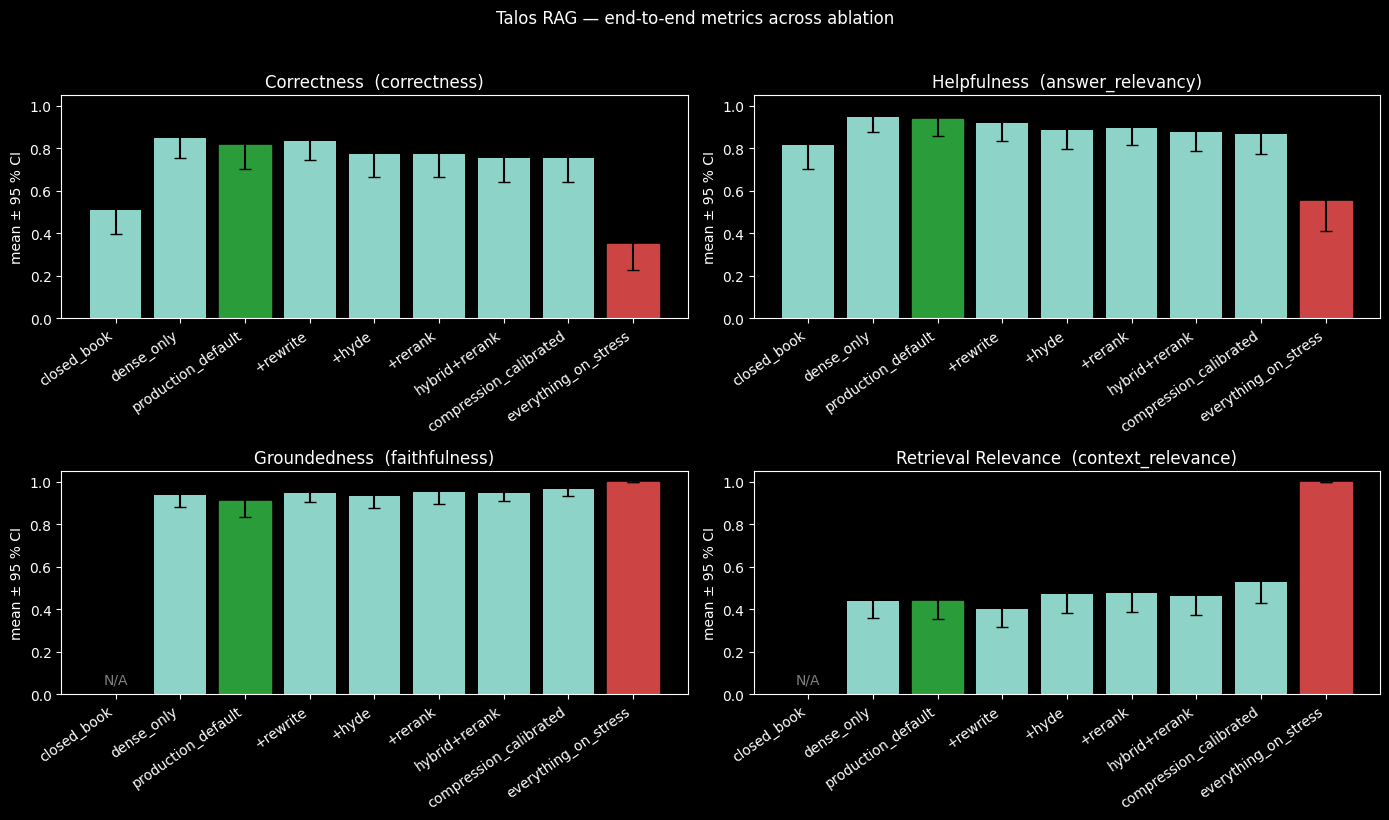

In [37]:
import matplotlib.pyplot as plt
import numpy as np

FRIEND_LABELS = {
    'correctness': 'Correctness',
    'answer_relevancy': 'Helpfulness',
    'faithfulness': 'Groundedness',
    'context_relevance': 'Retrieval Relevance',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()
order = [v.name for v in variants_cfg]
for ax, metric in zip(axes, FRIEND_LABELS):
    sub = summary_df[summary_df.metric == metric].set_index('variant').reindex(order)
    means = sub['mean'].values.astype(float)
    err_lo = np.where(np.isnan(means), 0, means - sub['lo'].values)
    err_hi = np.where(np.isnan(means), 0, sub['hi'].values - means)
    bars = ax.bar(range(len(order)), np.where(np.isnan(means), 0, means), yerr=[err_lo, err_hi], capsize=4)
    # Highlight production_default in green, broken stress variants in red.
    for i, name in enumerate(order):
        if name == 'production_default':
            bars[i].set_color('#2a9d3a')
        elif name == 'everything_on_stress':
            bars[i].set_color('#c44')
    for i, m in enumerate(means):
        if np.isnan(m):
            ax.text(i, 0.05, 'N/A', ha='center', color='grey', fontsize=10)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=35, ha='right')
    ax.set_title(f'{FRIEND_LABELS[metric]}  ({metric})')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('mean ± 95 % CI')
fig.suptitle('Talos RAG — end-to-end metrics across ablation', y=1.02)
plt.tight_layout()
plt.savefig(RUN_DIR / 'metrics_e2e.png', dpi=150, bbox_inches='tight')
plt.show()

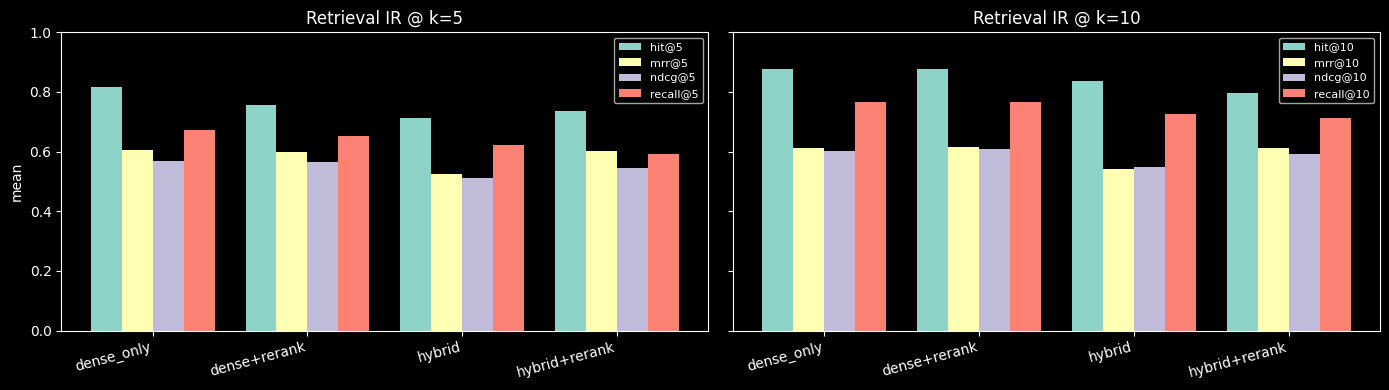

In [38]:
# Retrieval IR — both k=5 and k=10
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, k in zip(axes, [5, BEIR_K]):
    cols = [f'hit@{k}', f'mrr@{k}', f'ndcg@{k}', f'recall@{k}']
    ir_means = ir_df.groupby('retriever')[cols].mean().reindex([n for n,_ in retrieval_configs])
    x = np.arange(len(ir_means))
    width = 0.2
    for i, m in enumerate(ir_means.columns):
        ax.bar(x + i*width - 1.5*width, ir_means[m].values, width, label=m)
    ax.set_xticks(x); ax.set_xticklabels(ir_means.index, rotation=15, ha='right')
    ax.set_title(f'Retrieval IR @ k={k}')
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8)
axes[0].set_ylabel('mean')
plt.tight_layout()
plt.savefig(RUN_DIR / 'metrics_ir.png', dpi=150, bbox_inches='tight')
plt.show()

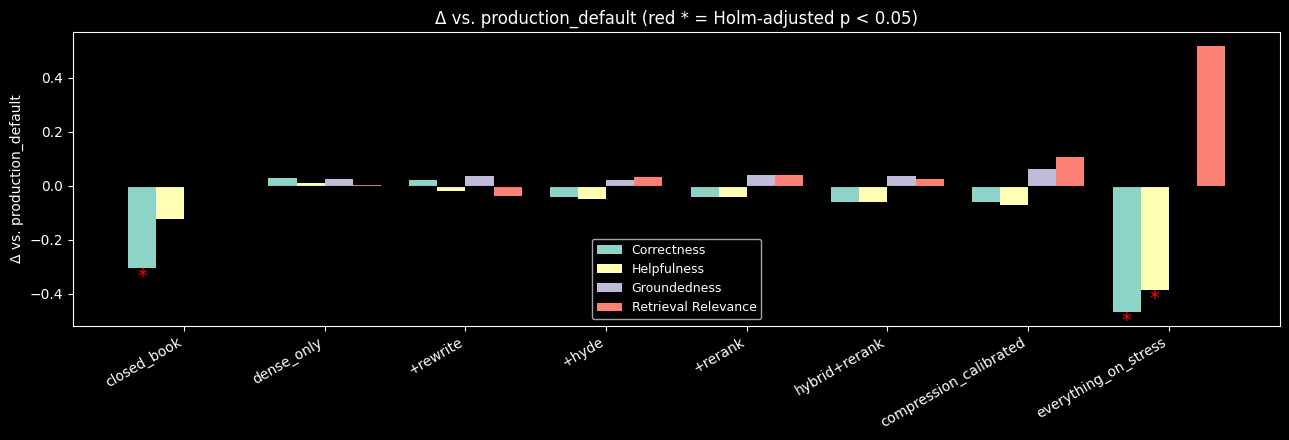

In [39]:
# Δ-vs-baseline + Holm-significance — Dror et al. 2018
if not stat_df.empty:
    pivot_d = stat_df.pivot(index='variant', columns='metric', values='delta_mean')
    pivot_p = stat_df.pivot(index='variant', columns='metric', values='p_holm')
    cols = ['correctness','answer_relevancy','faithfulness','context_relevance']
    cols = [c for c in cols if c in pivot_d.columns]
    var_order = [v.name for v in variants_cfg if v.name != BASELINE]
    pivot_d = pivot_d.reindex(var_order)[cols]
    pivot_p = pivot_p.reindex(var_order)[cols]
    fig, ax = plt.subplots(figsize=(13, 4.5))
    x = np.arange(len(var_order))
    width = 0.2
    for i, m in enumerate(cols):
        deltas = pivot_d[m].values.astype(float)
        pvals  = pivot_p[m].values.astype(float)
        bars = ax.bar(x + i*width - (len(cols)-1)*width/2, deltas, width, label=FRIEND_LABELS.get(m, m))
        for j, (d, p) in enumerate(zip(deltas, pvals)):
            if not np.isnan(p) and p < 0.05:
                ax.text(x[j] + i*width - (len(cols)-1)*width/2, d + (0.02 if d >= 0 else -0.05), '*', ha='center', fontsize=14, color='red')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(var_order, rotation=30, ha='right')
    ax.set_ylabel(f'Δ vs. {BASELINE}')
    ax.set_title(f'Δ vs. {BASELINE} (red * = Holm-adjusted p < 0.05)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(RUN_DIR / 'metrics_delta.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No paired-test table; skipping Δ plot.')

## 10 · Counterfactual-noise diagnostic — per category

Yoran et al., ICLR 2024 — feed random distractor chunks to the generator and re-grade Correctness; per-category split shows *where* retrieval is doing real work.

In [40]:
noise_rows = []
real = e2e_df[e2e_df.variant == BASELINE].set_index('qid')
var = variants[BASELINE]
for q in qa_items:
    if q.qid not in real.index:
        continue
    distractor_ctxs = eu.random_distractor_contexts(
        chunks, set(q.gold_chunk_ids or [q.gold_chunk_id]), k=TOP_K, seed=SEED + hash(q.qid)
    )
    noise_answer = var.answer_with_contexts(q.question, distractor_ctxs)
    noise_correct, _ = eu.judge_correctness(noise_answer, q.answer, q.question, judge)
    real_correct = real.loc[q.qid, 'correctness']
    noise_rows.append({
        'qid': q.qid, 'category': q.category,
        'real_correctness': real_correct,
        'noise_correctness': noise_correct,
        'correctness_drop': real_correct - noise_correct,
    })
noise_df = pd.DataFrame(noise_rows)
noise_df.to_csv(RUN_DIR / 'counterfactual_noise.csv', index=False)
if not noise_df.empty:
    print('Overall:')
    print(f'  Real:  {noise_df["real_correctness"].mean():.3f}')
    print(f'  Noise: {noise_df["noise_correctness"].mean():.3f}')
    print(f'  Drop:  {noise_df["correctness_drop"].mean():.3f}')
    print()
    print('Per-category:')
    print(noise_df.groupby('category')[['real_correctness','noise_correctness','correctness_drop']].mean().round(3))

Overall:
  Real:  0.816
  Noise: 0.224
  Drop:  0.592

Per-category:
                     real_correctness  noise_correctness  correctness_drop
category                                                                  
multi_hop_abstract              0.714              0.250             0.464
multi_hop_specific              0.682              0.182             0.500
single_hop_specific             0.938              0.229             0.708


## 11 · Closed-book lift — per category

Mallen et al., ACL 2023. Per-category split — popular / canonical questions are most likely memorised; long-tail questions show the largest RAG lift.

In [41]:
if 'closed_book' in e2e_df.variant.unique():
    cb_full = e2e_df[e2e_df.variant == 'closed_book']
    cb = cb_full.set_index('qid')['correctness']
    rows = []
    for vname in [v.name for v in variants_cfg if v.name != 'closed_book']:
        var = e2e_df[e2e_df.variant == vname].set_index(['qid', 'category'])['correctness']
        cbi = cb_full.set_index(['qid', 'category'])['correctness']
        common = var.index.intersection(cbi.index)
        if not len(common):
            continue
        for cat in sorted(set(c for _, c in common)):
            cat_idx = [(q, c) for q, c in common if c == cat]
            delta = (var.loc[cat_idx] - cbi.loc[cat_idx]).mean()
            rows.append({'variant': vname, 'category': cat, 'lift': round(float(delta), 3)})
        # Overall row
        delta_all = (var.loc[common] - cbi.loc[common]).mean()
        rows.append({'variant': vname, 'category': 'overall', 'lift': round(float(delta_all), 3)})
    lift_df = pd.DataFrame(rows)
    lift_df.to_csv(RUN_DIR / 'closed_book_lift.csv', index=False)
    pivot = lift_df.pivot(index='variant', columns='category', values='lift')
    pivot = pivot.reindex([v.name for v in variants_cfg if v.name != 'closed_book'])
    pivot

## 12 · 2-judge consistency check (Zheng et al. NeurIPS 2023 §4)

Re-judge a random 10-question slice of the production-default end-to-end answers with `gpt-4o` and report Pearson + Spearman correlation between the two judges. If correlation is high, the self-enhancement-bias caveat in §7 of the plan is empirically bounded.

In [42]:
if RUN_2JUDGE and alt_judge is not None:
    # Build the slice from production_default answers.
    pd_sub = e2e_df[e2e_df.variant == BASELINE].set_index('qid')
    cal_items = []
    for q in qa_items:
        if q.qid not in pd_sub.index:
            continue
        cal_items.append({
            'qid': q.qid,
            'question': q.question,
            'answer':   pd_sub.loc[q.qid, 'answer'],
            'reference': q.answer,
        })
    res2j = eu.two_judge_consistency(
        cal_items, judge, alt_judge, metric='correctness', sample_size=10, seed=SEED
    )
    print(f'2-judge slice on Correctness  (n={res2j["n"]}):')
    print(f'  primary ({JUDGE_MODEL})   mean: {res2j["primary_mean"]:.3f}')
    print(f'  alternative ({ALT_JUDGE_MODEL}) mean: {res2j["alternative_mean"]:.3f}')
    print(f'  Pearson r:  {res2j["pearson"]:.3f}')
    print(f'  Spearman ρ: {res2j["spearman"]:.3f}')
    print(f'  mean |Δ|:   {res2j["mean_abs_disagreement"]:.3f}')
    pd.DataFrame(res2j['rows']).to_csv(RUN_DIR / 'two_judge_consistency.csv', index=False)
else:
    print('2-judge check skipped (RUN_2JUDGE=False or ALT_JUDGE_MODEL=None).')

2-judge slice on Correctness  (n=10):
  primary (gpt-4o-mini)   mean: 0.800
  alternative (gpt-4o) mean: 0.850
  Pearson r:  0.921
  Spearman ρ: 0.986
  mean |Δ|:   0.050


## 13 · Compression-threshold sweep

The v2 run surfaced `EmbeddingsFilter(similarity_threshold=0.76)` as too aggressive for `text-embedding-3-small`: 44/49 questions had 0 chunks survive the filter and Correctness collapsed to 0.347. Sweep the threshold and recommend a calibrated value for the production config.

In [43]:
if RUN_COMP_SWEEP:
    sweep_thresholds = [0.30, 0.40, 0.50, 0.60, 0.76]
    sweep_rows = []
    for thr in sweep_thresholds:
        cfg = eu.VariantConfig(
            name=f'comp_{thr}', use_rerank=True,
            compression='embeddings', compression_threshold=thr, top_k=TOP_K,
        )
        v = eu.RagVariant(cfg, chunks, embeddings, generator,
                          base_vectorstore=base_vs, hyde_vectorstore=hyde_vs,
                          cache=eu.JsonCache(CACHE_DIR / f'compsweep_{thr}.json'))
        for q in qa_items:
            try:
                ans, retrieved = v.answer(q.question)
            except Exception as e:
                continue
            ctx = [d.page_content for d in retrieved]
            c, _ = eu.judge_correctness(ans, q.answer, q.question, judge)
            sweep_rows.append({
                'threshold': thr, 'qid': q.qid, 'category': q.category,
                'n_chunks_kept': len(retrieved), 'correctness': c,
            })
    sweep_df = pd.DataFrame(sweep_rows)
    sweep_df.to_csv(RUN_DIR / 'compression_sweep.csv', index=False)
    sweep_summary = (
        sweep_df.groupby('threshold')[['n_chunks_kept', 'correctness']]
                .mean().round(3)
    )
    print('Compression-threshold sweep (production_default + EmbeddingsFilter):')
    print(sweep_summary)
else:
    print('Compression sweep skipped.')

Compression-threshold sweep (production_default + EmbeddingsFilter):
           n_chunks_kept  correctness
threshold                            
0.30               5.000        0.847
0.40               4.898        0.827
0.50               4.408        0.806
0.60               2.082        0.663
0.76               0.143        0.357


## 14 · Human-calibration scaffold

Es et al. EACL 2024 §4 / Saad-Falcon et al. NAACL 2024: the LLM judge needs a small human-rated subset to validate its scoring. This cell exports a CSV template (~30 questions) for hand-rating Faithfulness and Answer Relevancy. After you fill it in, re-run the *next* cell to compute Pearson + Spearman of LLM-judge vs. human.

In [44]:
calibration_template = Path('human_calibration_template.csv')
calibration_filled  = Path('human_calibration_filled.csv')

if EXPORT_CALIBRATION:
    pd_sub = e2e_df[e2e_df.variant == BASELINE].set_index('qid')
    cal_rows = []
    rng_local = __import__('random').Random(SEED)
    sampled_qids = rng_local.sample(list(pd_sub.index), min(30, len(pd_sub)))
    for q in qa_items:
        if q.qid not in sampled_qids:
            continue
        row = pd_sub.loc[q.qid]
        cal_rows.append({
            'qid': q.qid,
            'question': q.question,
            'reference_answer': q.answer,
            'system_answer': row['answer'],
            'gold_chunk_text': q.gold_chunk_text[:2000],
            'llm_correctness': row['correctness'],
            'llm_faithfulness': row['faithfulness'],
            'llm_answer_relevancy': row['answer_relevancy'],
            'human_correctness': '',         # 0 / 0.5 / 1
            'human_faithfulness': '',        # 0 / 0.5 / 1
            'human_answer_relevancy': '',    # 0 / 0.5 / 1
            'human_notes': '',
        })
    pd.DataFrame(cal_rows).to_csv(calibration_template, index=False)
    print(f'Wrote calibration template: {calibration_template}')
    print(f'  → fill in the human_* columns (0 / 0.5 / 1), save as {calibration_filled.name},')
    print('  → then re-run the next cell to compute correlation.')

Wrote calibration template: human_calibration_template.csv
  → fill in the human_* columns (0 / 0.5 / 1), save as human_calibration_filled.csv,
  → then re-run the next cell to compute correlation.


In [45]:
if calibration_filled.exists():
    cal_df = pd.read_csv(calibration_filled)
    out_rows = []
    for metric in ['correctness', 'faithfulness', 'answer_relevancy']:
        llm_col   = f'llm_{metric}'
        human_col = f'human_{metric}'
        if human_col not in cal_df.columns:
            continue
        sub = cal_df[[llm_col, human_col]].dropna()
        sub[human_col] = pd.to_numeric(sub[human_col], errors='coerce')
        sub = sub.dropna()
        if len(sub) < 5:
            print(f'{metric}: only {len(sub)} hand-rated rows — fill in more.')
            continue
        pearson  = sub[llm_col].corr(sub[human_col], method='pearson')
        spearman = sub[llm_col].corr(sub[human_col], method='spearman')
        out_rows.append({
            'metric': metric, 'n': len(sub),
            'pearson_r': round(pearson, 3),
            'spearman_rho': round(spearman, 3),
            'mean_llm':   round(sub[llm_col].mean(), 3),
            'mean_human': round(sub[human_col].mean(), 3),
        })
    if out_rows:
        cal_summary = pd.DataFrame(out_rows)
        cal_summary.to_csv(RUN_DIR / 'human_calibration.csv', index=False)
        print('Judge ↔ human correlation:')
        print(cal_summary)
        print()
        print('Reading: pearson > 0.7 ⇒ judge is tracking human agreement well.')
        print('         pearson < 0.5 ⇒ swap to a stronger judge (gpt-4o) before reporting.')
else:
    print(f'No filled calibration file at {calibration_filled} — skip until ready.')

No filled calibration file at human_calibration_filled.csv — skip until ready.


## ~~15 · HotpotQA~~ — dropped

HotpotQA was scoped out of this notebook. Of 500 random HotpotQA validation questions, **zero** had any gold supporting article matching our 200-article CS corpus — HotpotQA is general-knowledge Wikipedia (people, places, history) and our corpus is narrow-domain CS. The intersection is empty even with loose matching.

The replacement is `rag_evaluation_talos.ipynb` — the same evaluation pipeline run against a Talos-realistic corpus (CS course PDFs / API docs / recent CS papers / the project's own `docs/`). That corpus directly approximates what Talos workspaces hold.

## 16 · Per-category ablation breakdown

In [47]:
lift = (
    e2e_df.groupby(['variant','category'])[['correctness','faithfulness','answer_relevancy','context_relevance']]
          .mean().round(3)
)
lift.to_csv(RUN_DIR / 'per_category.csv')
lift

correctness  faithfulness  \
variant                category                                         
+hyde                  multi_hop_abstract         0.750         1.000   
                       multi_hop_specific         0.682         0.816   
                       single_hop_specific        0.833         0.948   
+rerank                multi_hop_abstract         0.786         0.991   
                       multi_hop_specific         0.682         0.909   
                       single_hop_specific        0.812         0.948   
+rewrite               multi_hop_abstract         0.821         0.991   
                       multi_hop_specific         0.727         0.886   
                       single_hop_specific        0.896         0.949   
closed_book            multi_hop_abstract         0.679           NaN   
                       multi_hop_specific         0.455           NaN   
                       single_hop_specific        0.438           NaN   
compression_calibrated multi_hop_abstract         0.750         0.991   
                       multi_hop_specific         0.682         0.950   
                       single_hop_specific        0.792         0.960   
dense_only             multi_hop_abstract         0.786         0.982   
                       multi_hop_specific         0.727         0.930   
                       single_hop_specific        0.938         0.916   
everything_on_stress   multi_hop_abstract         0.250           NaN   
                       multi_hop_specific         0.364         1.000   
                       single_hop_specific        0.396         1.000   
hybrid+rerank          multi_hop_abstract         0.679         0.964   
                       multi_hop_specific         0.636         0.921   
                       single_hop_specific        0.854         0.950   
production_default     multi_hop_abstract         0.714         1.000   
                       multi_hop_specific         0.682         0.799   
                       single_hop_specific        0.938         0.911   

                                            answer_relevancy  \
variant                category                                
+hyde                  multi_hop_abstract              0.857   
                       multi_hop_specific              0.955   
                       single_hop_specific             0.875   
+rerank                multi_hop_abstract              0.929   
                       multi_hop_specific              0.909   
                       single_hop_specific             0.875   
+rewrite               multi_hop_abstract              0.893   
                       multi_hop_specific              0.955   
                       single_hop_specific             0.917   
closed_book            multi_hop_abstract              0.750   
                       multi_hop_specific              0.727   
                       single_hop_specific             0.896   
compression_calibrated multi_hop_abstract              0.857   
                       multi_hop_specific              0.818   
                       single_hop_specific             0.896   
dense_only             multi_hop_abstract              0.929   
                       multi_hop_specific              0.955   
                       single_hop_specific             0.958   
everything_on_stress   multi_hop_abstract              0.286   
                       multi_hop_specific              0.591   
                       single_hop_specific             0.688   
hybrid+rerank          multi_hop_abstract              0.857   
                       multi_hop_specific              0.909   
                       single_hop_specific             0.875   
production_default     multi_hop_abstract              0.857   
                       multi_hop_specific              1.000   
                       single_hop_specific             0.958   

                                            context_relevance  
varia

## 17 · Save run manifest

In [48]:
manifest = {
    'eval_version': 'v3',
    'seed': SEED, 'n_articles': N_ARTICLES, 'n_questions_target': N_QUESTIONS,
    'min_test_set_size': MIN_TEST_SET_SIZE, 'min_n_for_stats': MIN_N_FOR_STATS,
    'top_k': TOP_K, 'beir_k': BEIR_K,
    'generator_model': GENERATOR_MODEL, 'judge_model': JUDGE_MODEL,
    'alt_judge_model': ALT_JUDGE_MODEL if RUN_2JUDGE else None,
    'embedding_model': EMBEDDING_MODEL,
    'corpus': str(CORPUS_PATH),
    'n_chunks': len(chunks),
    'n_qa_items': len(qa_items),
    'qa_categories': dict(Counter(q.category for q in qa_items)),
    'variants': [asdict(v) for v in variants_cfg],
    'baseline_for_paired_tests': BASELINE,
    'flags': {
        'run_2judge': RUN_2JUDGE,
        'run_comp_sweep': RUN_COMP_SWEEP,
        'run_hotpot': RUN_HOTPOT,
        'export_calibration': EXPORT_CALIBRATION,
    },
    'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
}
(RUN_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print('Wrote', RUN_DIR / 'manifest.json')
print('Artifacts in this run:')
for p in sorted(RUN_DIR.iterdir()):
    print(' -', p.name)

Wrote runs/20260428-092956/manifest.json
Artifacts in this run:
 - closed_book_lift.csv
 - compression_sweep.csv
 - counterfactual_noise.csv
 - e2e_per_question.csv
 - manifest.json
 - metrics_delta.png
 - metrics_e2e.png
 - metrics_ir.png
 - oracle_generation.csv
 - paired_tests.csv
 - per_category.csv
 - retrieval_ir.csv
 - retrieval_ir_summary.csv
 - summary.csv
 - two_judge_consistency.csv


## 18 · How to read these results

The defensible report claim is:

1. **`production_default` is the headline row** in §8 — the number to put in the abstract / conclusion.
2. **§7 paired Wilcoxon vs. `production_default`** — only rows with `significant == True` (Holm-corrected p < 0.05) are real wins or regressions.
3. **§9 Δ-vs-baseline plot** — red `*` marks Holm-significant differences. If a variant has no `*`, you cannot defensibly claim it improves on production.
4. **§10 noise-drop per category** — large drops ⇒ retrieval is doing real work in that category.
5. **§11 closed-book lift per category** — large lift ⇒ retrieval is needed to answer those questions; near-zero lift ⇒ the model already knew it (Wikipedia memorisation).
6. **§12 2-judge consistency** — Pearson > 0.7 ⇒ the LLM judge is tracking a stronger model's agreement; cite this when defending against "how do you know the judge is right?".
7. **§13 compression sweep** — the threshold that maximises Correctness should be the value used in `src/rag/retrieval/compression.py`, *if* compression is enabled at all.
8. **§14 human calibration** — fill in `human_calibration_filled.csv` after the run, then re-execute the second cell of §14. Pearson > 0.7 between `gpt-4o-mini` judge and human ratings is the strongest validity claim available.
9. **§15 HotpotQA** — if enabled, this is the second-strongest evidence (human-written multi-hop questions with gold supporting facts).

Methodology details and references: [`EVALUATION_PLAN.md`](EVALUATION_PLAN.md).